In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
%matplotlib inline

In [3]:
df = pd.read_csv("../data/cleaned_songs.csv")

In [4]:
df.shape
df.head()

,name,album,artist,id,release_date,popularity,length,danceability,acousticness,energy,instrumentalness,liveness,valence,loudness,speechiness,tempo,key,time_signature,mood
0,1999,1999,Prince,2H7PHVdQ3mXqEHXcvclTB0,1982-10-27,68,379266,0.866,0.13700,0.730,0.000000,0.0843,0.625,-8.201,0.0767,118.523,5,4,Happy
1,23,23,Blonde Redhead,4HIwL9ii9CcXpTOTzMq0MP,2007-04-16,43,318800,0.381,0.01890,0.832,0.196000,0.1530,0.166,-5.069,0.0492,120.255,8,4,Sad
2,9 Crimes,9,Damien Rice,5GZEeowhvSieFDiR8fQ2im,2006-11-06,60,217946,0.346,0.91300,0.139,0.000077,0.0934,0.116,-15.326,0.0321,136.168,0,4,Sad
3,99 Luftballons,99 Luftballons,Nena,6HA97v4wEGQ5TUClRM0XLc,1984-08-21,2,233000,0.466,0.08900,0.438,0.000006,0.1130,0.587,-12.858,0.0608,193.100,4,4,Happy
4,A Boy Brushed Red Living In Black And White,They're Only Chasing Safety,Underoath,47IWLfIKOKhFnz1FUEUIkE,2004-01-01,60,268000,0.419,0.00171,0.932,0.000000,0.1370,0.445,-3.604,0.1060,169.881,1,4,Energetic


In [5]:
#selecting the features + scaling them

features = [
    "danceability", "energy", "valence", "tempo", "acousticness",
    "instrumentalness", "speechiness"]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaling shape:", X_scaled.shape)

Scaling shape: (686, 7)


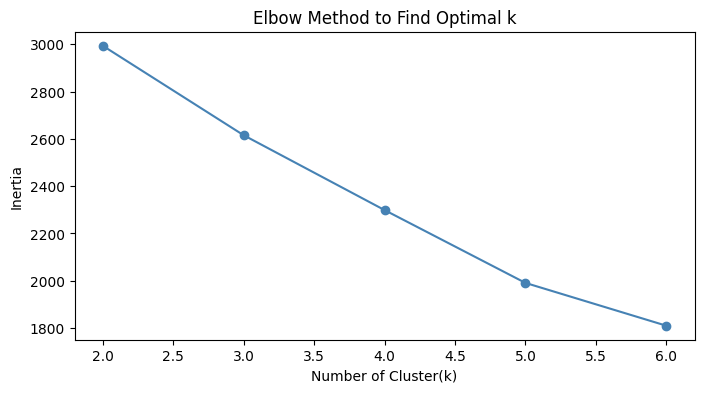

In [6]:
#Elbow method
inertia = []
k_range = range(2, 7)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init = 10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.xlabel("Number of Cluster(k)")
plt.ylabel("Inertia")
plt.title("Elbow Method to Find Optimal k")
plt.savefig("../plots/elbow_plot.png", dpi=150)
plt.show()

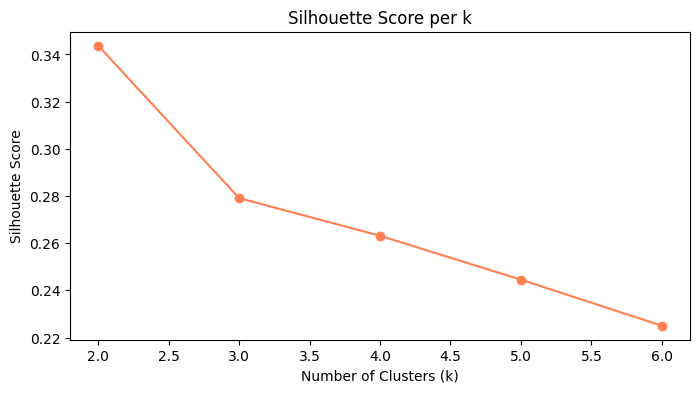

In [7]:
#silhouette score per k
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8,4))
plt.plot(k_range, silhouette_scores, marker='o', color='coral')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score per k")
plt.savefig("../plots/silhouette_per_k.png", dpi=150)
plt.show()

    

In [8]:
#deciding whether to include loudness in features or not
#as it is very similar to energy and wouldn't want the KMeans clustering
#model to count for it twice - need to be more effective

features_no_loudness = [
    "danceability", "energy", "valence", "tempo", "acousticness", 
    "instrumentalness", "speechiness"
]

features_with_loudness = [
    "danceability", "energy", "valence", "tempo", "acousticness", 
    "instrumentalness", "speechiness", "loudness"
]

X_no_loud = StandardScaler().fit_transform(df[features_no_loudness])
X_with_loud = StandardScaler().fit_transform(df[features_with_loudness])

OPTIMAL_K = 4

score_no_loudness = silhouette_score(X_no_loud,
                    KMeans(n_clusters=OPTIMAL_K, random_state=42,
                    n_init=10).fit_predict(X_no_loud))

score_with_loud = silhouette_score(X_with_loud,
                  KMeans(n_clusters=OPTIMAL_K, random_state=42,
                  n_init=10).fit_predict(X_with_loud))

print(f"Silhouette Score WITHOUT loudness: {score_no_loudness:.4f}")
print(f"Silhouette Score WITH loudness:    {score_with_loud:.4f}")
print(f"\nBetter feature set: {'Without loudness' if score_no_loudness > score_with_loud else 'With loudness'}")

Silhouette Score WITHOUT loudness: 0.2631
Silhouette Score WITH loudness:    0.2371

Better feature set: Without loudness


In [9]:
#final K-Means Model
OPTIMAL_K = 4
km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df["cluster"] = km_final.fit_predict(X_scaled)
print(df["cluster"].value_counts())
df.to_csv("../data/clustered_spotify.csv", index=False)


cluster
2    306
3    219
1    130
0     31
Name: count, dtype: int64


In [10]:
#final silhouette score
score = silhouette_score(X_scaled, df["cluster"])
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.2631


         danceability    energy   valence       tempo  acousticness  \
cluster                                                               
0            0.510677  0.851645  0.423871  136.478935      0.088607   
1            0.493708  0.318657  0.250015  115.803346      0.707031   
2            0.569095  0.789595  0.505852  126.498147      0.083217   
3            0.407412  0.177330  0.157441  108.368379      0.860286   

         instrumentalness  speechiness  
cluster                                 
0                0.027376     0.202839  
1                0.066618     0.038929  
2                0.127986     0.055209  
3                0.872877     0.040019  


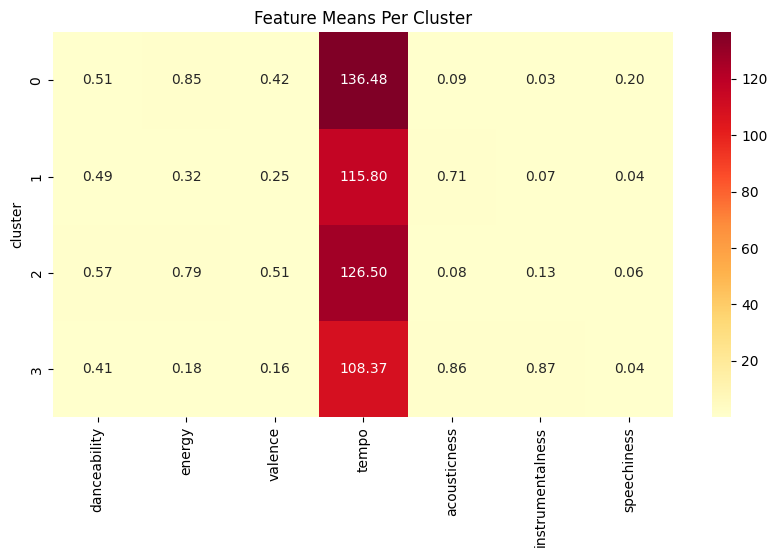

In [11]:
cluster_profile = df.groupby("cluster")[features].mean()
print(cluster_profile)

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profile, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Feature Means Per Cluster")
plt.savefig("../plots/feature_means_heatmap.png", dpi=150)
plt.show()

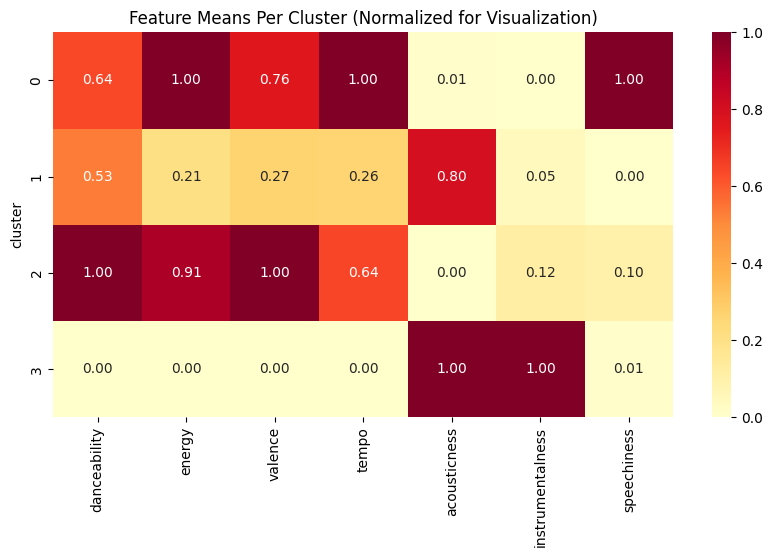

In [12]:
#normalizing cluster profile for the visualization since above
#makes it look like tempo is really important compared to other features
#and scaling is off
from sklearn.preprocessing import MinMaxScaler

viz_scaler = MinMaxScaler()
cluster_profile_normalized = pd.DataFrame(
    viz_scaler.fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profile_normalized, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Feature Means Per Cluster (Normalized for Visualization)")
plt.savefig("../plots/feature_means_heatmap_normalized.png", dpi=150)
plt.show()


mood     Calm  Energetic  Happy  Sad
cluster                             
0           0         19      9    3
1           1          1      5  123
2           3        134    126   43
3         191          0      0   28


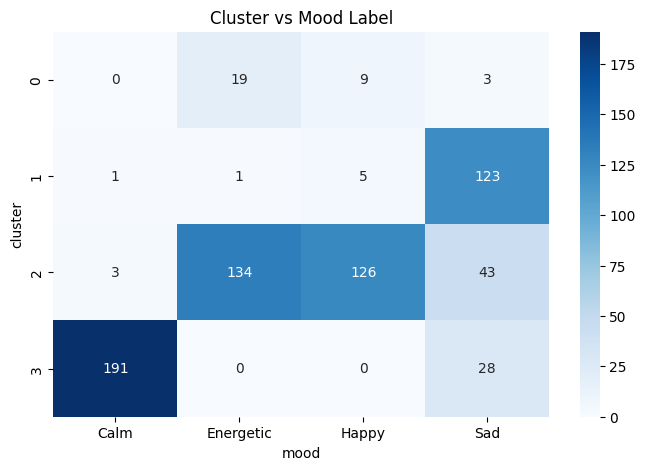

In [14]:
comparison = pd.crosstab(df["cluster"], df["mood"])
print(comparison)

plt.figure(figsize=(8, 5))
sns.heatmap(comparison, annot=True, fmt="d", cmap="Blues")
plt.title("Cluster vs Mood Label")
plt.savefig("../plots/mood_heatmap.png", dpi=150)
plt.show()

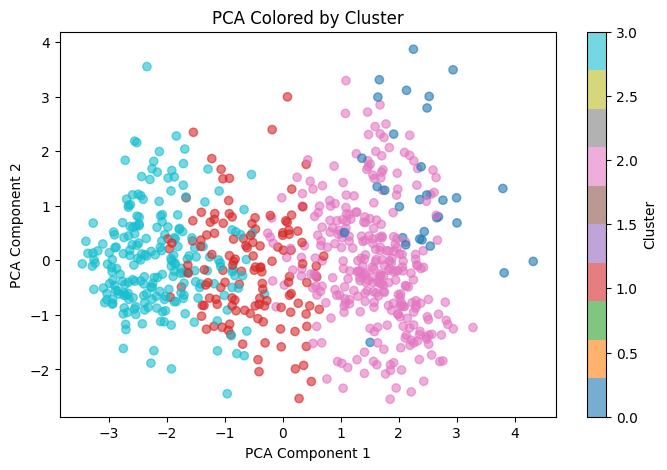

In [15]:
#PCA colored by cluster
pca = PCA(n_components=2) #creating a PCA object to compress data to 2 components
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
#X-axis and y-axis
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df["cluster"], cmap="tab10", alpha=0.6)
plt.colorbar(scatter, label="Cluster")
plt.title("PCA Colored by Cluster")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.savefig("../plots/pca_cluster.png", dpi=150)
plt.show()

In [ ]:
#PCA colored by mood